# Cyberbullying Classification Model
**Dataset:** cyberbullying-classification from Kaggle

This notebook covers:
1. Exploratory Data Analysis (EDA)
2. Data Cleaning & Preprocessing
3. Feature Engineering with TF-IDF
4. Model Building (Naive Bayes & Random Forest)
5. Model Evaluation

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data

In [2]:
df = pd.read_csv('cyberbullying_tweets.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Dataset shape: (47692, 2)

Column names: ['tweet_text', 'cyberbullying_type']


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


## 2. Exploratory Data Analysis (EDA)

### 2.1 Check for Missing Values

In [4]:
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values:
tweet_text            0
cyberbullying_type    0
dtype: int64

Total missing values: 0


### 2.2 Check for Duplicate Rows

In [5]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"After removing duplicates: {df.shape[0]} rows")

Number of duplicate rows: 36
After removing duplicates: 47656 rows


### 2.3 Target Distribution

In [6]:
print("Target Distribution:")
df['cyberbullying_type'].value_counts()

Target Distribution:


cyberbullying_type
religion               7997
age                    7992
ethnicity              7959
gender                 7948
not_cyberbullying      7937
other_cyberbullying    7823
Name: count, dtype: int64

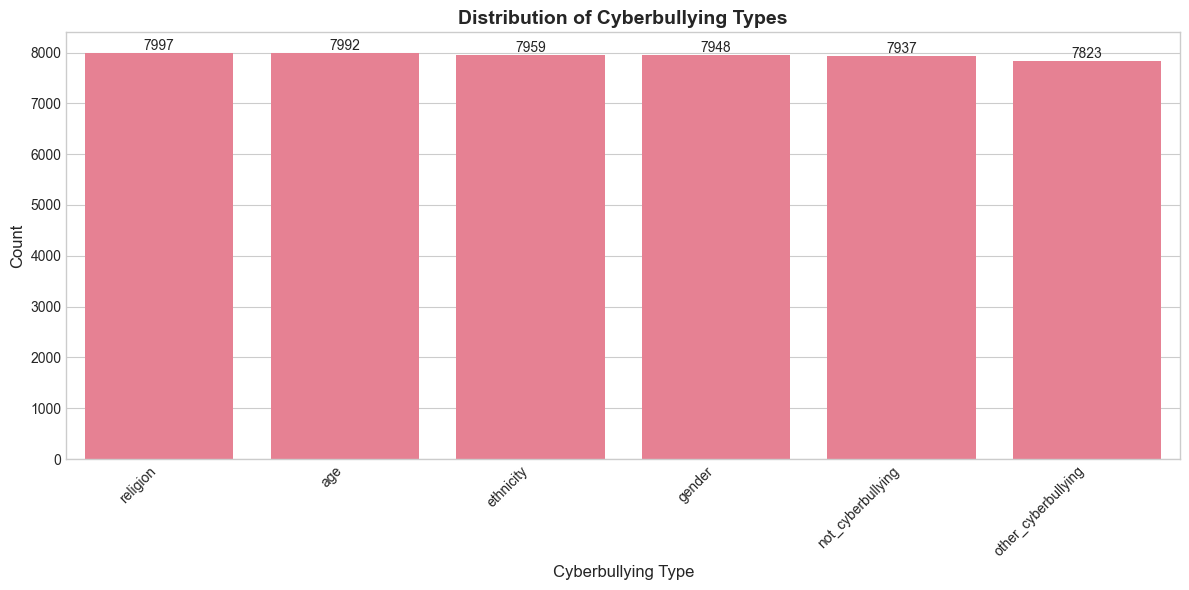

In [7]:
# Visualize target distribution with count plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='cyberbullying_type', order=df['cyberbullying_type'].value_counts().index)
plt.title('Distribution of Cyberbullying Types', fontsize=14, fontweight='bold')
plt.xlabel('Cyberbullying Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

### 2.4 WordCloud for Bullying vs Non-Bullying

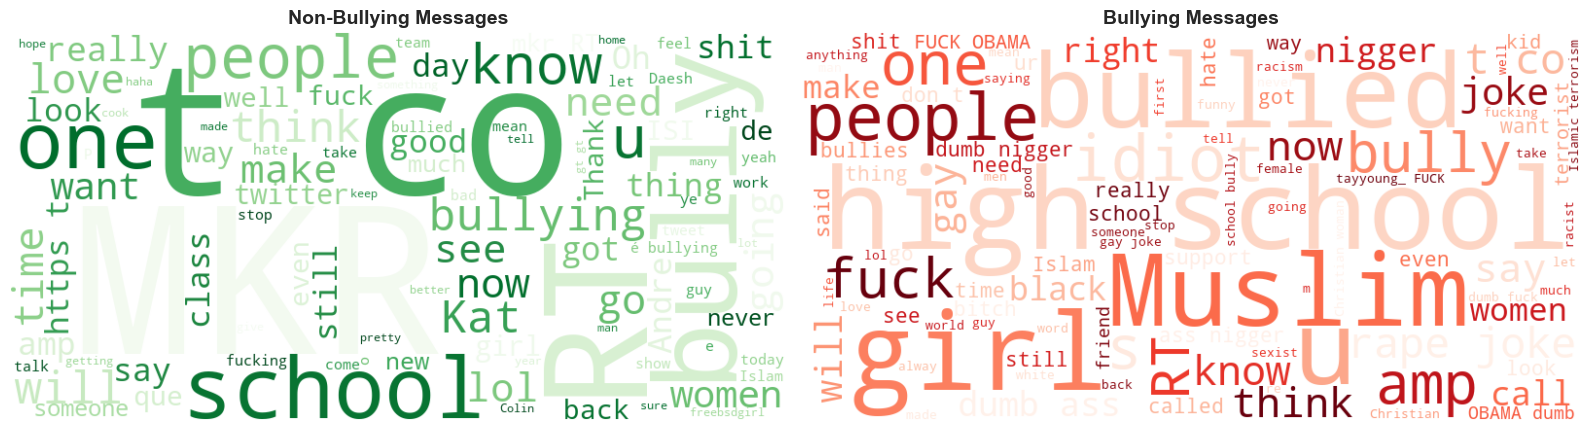

In [8]:
# Separate bullying and non-bullying messages
non_bullying_text = ' '.join(df[df['cyberbullying_type'] == 'not_cyberbullying']['tweet_text'].astype(str))
bullying_text = ' '.join(df[df['cyberbullying_type'] != 'not_cyberbullying']['tweet_text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# WordCloud for Non-Bullying
wordcloud_non_bully = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(non_bullying_text)

axes[0].imshow(wordcloud_non_bully, interpolation='bilinear')
axes[0].set_title('Non-Bullying Messages', fontsize=14, fontweight='bold')
axes[0].axis('off')

# WordCloud for Bullying
wordcloud_bully = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(bullying_text)

axes[1].imshow(wordcloud_bully, interpolation='bilinear')
axes[1].set_title('Bullying Messages', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

## 3. Data Cleaning & Preprocessing

### 3.1 Text Cleaning Function

In [9]:
def clean_text(text):
    """
    Clean text by removing URLs, handles, hashtags, and special characters.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user handles (@user)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove HTML entities
    text = re.sub(r'&\w+;', '', text)

    # Remove special characters and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("Text cleaning function defined!")

Text cleaning function defined!


In [10]:
# Apply cleaning
print("Cleaning text data...")
df['cleaned_text'] = df['tweet_text'].apply(clean_text)

# Remove rows with empty cleaned text
original_len = len(df)
df = df[df['cleaned_text'].str.len() > 0]
print(f"Removed {original_len - len(df)} rows with empty text after cleaning")

Cleaning text data...
Removed 398 rows with empty text after cleaning


In [11]:
# Sample comparison of original vs cleaned text
print("Sample cleaned text comparison:")
print("=" * 80)
for i in range(3):
    print(f"Original: {df['tweet_text'].iloc[i][:80]}...")
    print(f"Cleaned:  {df['cleaned_text'].iloc[i][:80]}...")
    print("-" * 80)

Sample cleaned text comparison:
Original: In other words #katandandre, your food was crapilicious! #mkr...
Cleaned:  in other words your food was crapilicious...
--------------------------------------------------------------------------------
Original: Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studi...
Cleaned:  why is so white...
--------------------------------------------------------------------------------
Original: @XochitlSuckkks a classy whore? Or more red velvet cupcakes?...
Cleaned:  a classy whore or more red velvet cupcakes...
--------------------------------------------------------------------------------


### 3.2 Label Encoding

In [12]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['cyberbullying_type'])

# Display label mapping
print("Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i}: {label} ({count} samples)")

Label Mapping:
  0: age (7992 samples)
  1: ethnicity (7952 samples)
  2: gender (7910 samples)
  3: not_cyberbullying (7805 samples)
  4: other_cyberbullying (7602 samples)
  5: religion (7997 samples)


## 4. Feature Engineering - TF-IDF Vectorization

In [13]:
# Prepare features and target
X = df['cleaned_text']
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 37806
Test set size: 9452


In [14]:
# TF-IDF Vectorization with ngram_range=(1,2)
print("Applying TF-IDF Vectorization with ngram_range=(1,2)...")
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),      # Unigrams and bigrams
    max_features=10000,      # Limit vocabulary size
    min_df=5,                # Ignore terms appearing in < 5 documents
    max_df=0.95,             # Ignore terms appearing in > 95% of documents
    stop_words='english'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

Applying TF-IDF Vectorization with ngram_range=(1,2)...
TF-IDF matrix shape (train): (37806, 10000)
TF-IDF matrix shape (test): (9452, 10000)
Vocabulary size: 10000


In [15]:
# Display sample features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Sample features (first 20):")
print(feature_names[:20].tolist())

Sample features (first 20):
['aa', 'ab', 'abandoned', 'abdul', 'ability', 'able', 'ableist', 'abortion', 'abortion jokes', 'abortion providers', 'abortions', 'abroad', 'absolute', 'absolutely', 'absurd', 'abt', 'abt rape', 'abuse', 'abuse jokes', 'abuse rape']


## 5. Model Building

### 5.1 Multinomial Naive Bayes

In [16]:
print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print("Naive Bayes model trained successfully!")

Training Multinomial Naive Bayes...
Naive Bayes model trained successfully!


### 5.2 Random Forest Classifier

In [17]:
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print("Random Forest model trained successfully!")

Training Random Forest Classifier...
Random Forest model trained successfully!


## 6. Model Evaluation

In [18]:
def evaluate_model(y_true, y_pred, model_name, label_encoder):
    """Evaluate model and display metrics."""
    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")

    # Precision, Recall, F1-Score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")

    # Classification Report
    print(f"\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    return accuracy, precision, recall, f1

### 6.1 Evaluate Naive Bayes

In [19]:
acc_nb, prec_nb, rec_nb, f1_nb = evaluate_model(
    y_test, y_pred_nb, "Multinomial Naive Bayes", label_encoder
)


Multinomial Naive Bayes Results

Accuracy: 0.7566
Precision (weighted): 0.7466
Recall (weighted): 0.7566
F1-Score (weighted): 0.7471

--- Classification Report ---
                     precision    recall  f1-score   support

                age       0.83      0.96      0.89      1599
          ethnicity       0.88      0.88      0.88      1590
             gender       0.86      0.76      0.81      1582
  not_cyberbullying       0.55      0.41      0.47      1561
other_cyberbullying       0.55      0.54      0.55      1520
           religion       0.79      0.96      0.87      1600

           accuracy                           0.76      9452
          macro avg       0.74      0.75      0.74      9452
       weighted avg       0.75      0.76      0.75      9452



### 6.2 Evaluate Random Forest

In [20]:
acc_rf, prec_rf, rec_rf, f1_rf = evaluate_model(
    y_test, y_pred_rf, "Random Forest", label_encoder
)


Random Forest Results

Accuracy: 0.7814
Precision (weighted): 0.7937
Recall (weighted): 0.7814
F1-Score (weighted): 0.7837

--- Classification Report ---
                     precision    recall  f1-score   support

                age       0.94      0.98      0.96      1599
          ethnicity       0.96      0.96      0.96      1590
             gender       0.93      0.74      0.82      1582
  not_cyberbullying       0.48      0.62      0.54      1561
other_cyberbullying       0.51      0.44      0.47      1520
           religion       0.93      0.94      0.94      1600

           accuracy                           0.78      9452
          macro avg       0.79      0.78      0.78      9452
       weighted avg       0.79      0.78      0.78      9452



## 7. Confusion Matrix Heatmaps

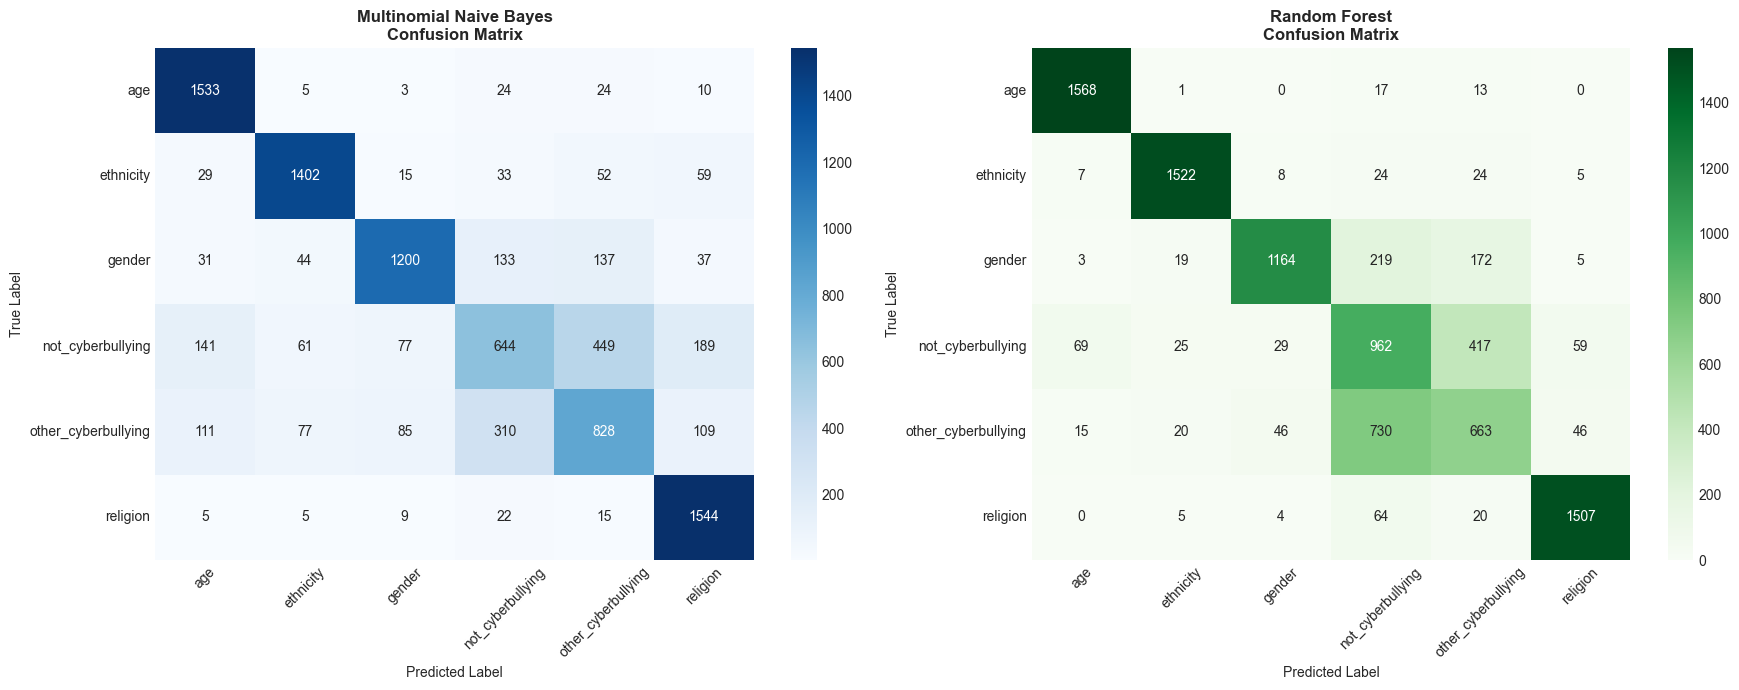

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[0]
)
axes[0].set_title('Multinomial Naive Bayes\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[1]
)
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## 8. Model Comparison Summary

In [22]:
comparison_df = pd.DataFrame({
    'Model': ['Multinomial Naive Bayes', 'Random Forest'],
    'Accuracy': [acc_nb, acc_rf],
    'Precision': [prec_nb, prec_rf],
    'Recall': [rec_nb, rec_rf],
    'F1-Score': [f1_nb, f1_rf]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.756559,0.746595,0.756559,0.747099
1,Random Forest,0.781422,0.793689,0.781422,0.783701


In [23]:
# Identify best model
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
best_f1 = comparison_df.loc[best_model_idx, 'F1-Score']
print(f"Best Model: {best_model} (F1-Score: {best_f1:.4f})")

Best Model: Random Forest (F1-Score: 0.7837)


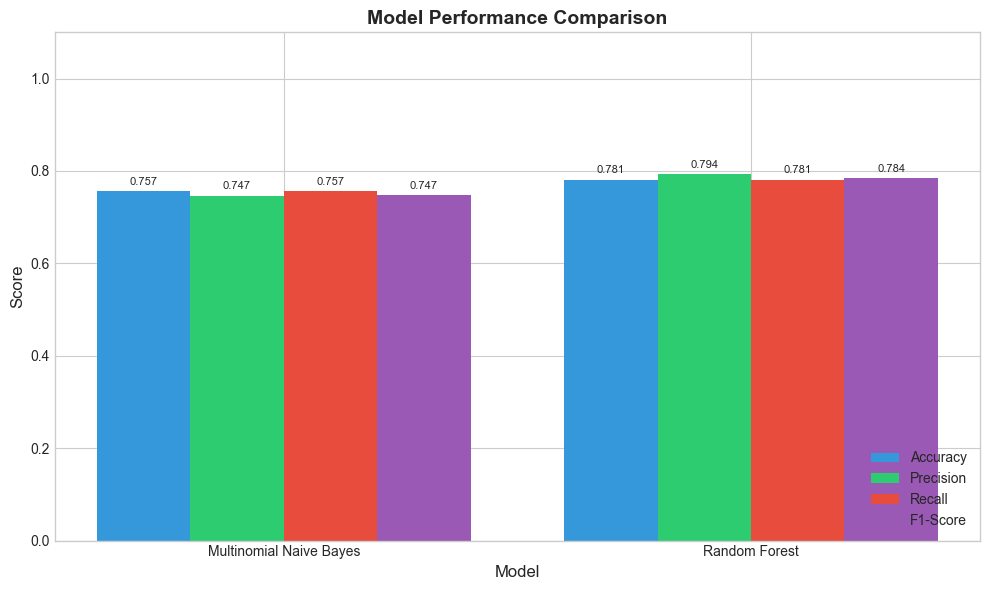

In [24]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, comparison_df[metric], width, label=metric, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'])
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 9. Sample Predictions

In [25]:
# Select best model for predictions
if best_model == 'Multinomial Naive Bayes':
    best_classifier = nb_model
else:
    best_classifier = rf_model

# Test with sample messages
sample_messages = [
    "You are so stupid and ugly, nobody likes you!",
    "Great job on the presentation today!",
    "Go back to your country, you don't belong here",
    "I hope you have a wonderful day!",
    "Women shouldn't be allowed to work"
]

print(f"Using {best_model} for predictions:\n")
print("=" * 60)
for msg in sample_messages:
    cleaned = clean_text(msg)
    vectorized = tfidf_vectorizer.transform([cleaned])
    prediction = best_classifier.predict(vectorized)[0]
    pred_label = label_encoder.inverse_transform([prediction])[0]
    print(f"Message: \"{msg}\"")
    print(f"Prediction: {pred_label}")
    print("-" * 60)

Using Random Forest for predictions:

Message: "You are so stupid and ugly, nobody likes you!"
Prediction: other_cyberbullying
------------------------------------------------------------
Message: "Great job on the presentation today!"
Prediction: not_cyberbullying
------------------------------------------------------------
Message: "Go back to your country, you don't belong here"
Prediction: religion
------------------------------------------------------------
Message: "I hope you have a wonderful day!"
Prediction: not_cyberbullying
------------------------------------------------------------
Message: "Women shouldn't be allowed to work"
Prediction: not_cyberbullying
------------------------------------------------------------


## Analysis Complete!

**Output files generated:**
- `target_distribution.png`
- `wordclouds.png`
- `confusion_matrices.png`
- `model_comparison.png`